In [46]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:

# -------------------------
# Step 1: Load Dataset
# -------------------------
df = pd.read_csv("city_remin_gemini_mmi.csv")

# -------------------------
# Step 2: Clean & Prepare Data
# Roman numeral to integer mapping for MMI scale
mmi_mapping = {
    'I': 1, 'II': 2, 'III': 3, 'IV': 4, 'V': 5,
    'VI': 6, 'VII': 7, 'VIII': 8, 'IX': 9, 'X': 10,
    'XI': 11, 'XII': 12
}

# Apply the mapping to the MMI column
df['MMI_numeric'] = df['MMI'].map(mmi_mapping)
# -------------------------
df_clean = df[['City', 'damage_lev', 'MMI_numeric', 'Distance']].dropna()

# Clean Distance column (e.g., "295 km" → 295)
df_clean['Distance'] = (
    df_clean['Distance']
    .astype(str)
    .str.replace('km', '', case=False)
    .str.replace(',', '')
    .str.strip()
)
df_clean['Distance'] = pd.to_numeric(df_clean['Distance'], errors='coerce')
df_clean = df_clean.dropna(subset=['Distance'])



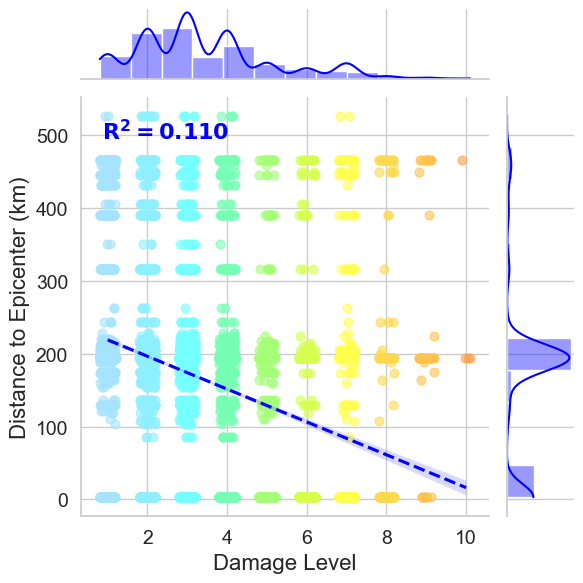

In [67]:
# -------------------------
# Step 3: Filter Cities with ≥10 Tweets
# -------------------------
city_counts = df_clean['City'].value_counts()
valid_cities = city_counts[city_counts >= 10].index
df_clean = df_clean[df_clean['City'].isin(valid_cities)].copy()

# -------------------------
# Step 4: Add MMI Category and Jitter
# -------------------------
df_clean['MMI_predicted_num'] = df_clean['damage_lev'].round().astype(int)

jitter_amount = 0.2
np.random.seed(42)
df_clean['x_jittered'] = df_clean['MMI_predicted_num'] + np.random.uniform(
    -jitter_amount, jitter_amount, size=len(df_clean)
)

# -------------------------
# Step 5: Regression (non-jittered)
# -------------------------
X_ = df_clean['MMI_predicted_num'].values.reshape(-1, 1)
y_ = df_clean['Distance'].values
model = LinearRegression().fit(X_, y_)
slope, intercept = model.coef_[0], model.intercept_
r_squared = r2_score(y_, model.predict(X_))

# -------------------------
# Step 6: Joint Plot with Style
# -------------------------
sns.set(style='whitegrid', context='notebook')
#sns.set_theme(style="darkgrid")
g = sns.JointGrid(data=df_clean, x='x_jittered', y='Distance', height=6)

# Scatter plot by MMI level color

palette = sns.color_palette("Spectral", n_colors=df_clean['MMI_predicted_num'].nunique())

mmi_colors = {
    1: "#a6e3ff",  # Light blue
    2: "#8ef0ff",  # Bright cyan
    3: "#76ffff",  # Lighter cyan
    4: "#76ffb4",  # Mint green
    5: "#a5ff76",  # Light green
    6: "#d6ff4d",  # Yellow-green
    7: "#ffff4d",  # Yellow
    8: "#ffd94d",  # Yellow-orange
    9: "#ffc24d",  # Orange
    10: "#ffa14d", # Deep orange
}

mmi_levels = sorted(df_clean['MMI_predicted_num'].unique())
for level in mmi_levels:
    subset = df_clean[df_clean['MMI_predicted_num'] == level]
    g.ax_joint.scatter(
        subset['x_jittered'],
        subset['Distance'],
        label=f"MMI {level}",
        alpha=0.6,
        s=40,
        color=mmi_colors.get(level, "gray")  # fallback to gray
    )

# Regression line
sns.regplot(
    x='MMI_predicted_num', y='Distance', data=df_clean,
    scatter=False, ax=g.ax_joint,
    color='blue',
    line_kws={'linestyle': '--'}
)

# Top marginal (histogram + KDE)
sns.histplot(df_clean['x_jittered'], ax=g.ax_marg_x, bins=12, kde=True, color='blue', alpha=0.4)


# Right marginal: histogram only (no KDE)
sns.histplot(
    data=df_clean,
    y='Distance',
    ax=g.ax_marg_y,
    bins=12, kde=True,
    color='blue',
    alpha=0.4,
    #element='bars'  # ensures classic bar look
)


# Right marginal KDE (replacing earlier kdeplot + histplot combo)
#sns.kdeplot(
#    data=df_clean,
#    y='Distance',
#    ax=g.ax_marg_y,
#    bw_adjust=0.5,        # Smooth and wider
#    fill=True,
#    color='m',
#    alpha=0.4,
#    linewidth=1.5
#)

#counts, bins = np.histogram(df_clean['Distance'], bins=20)
#g.ax_marg_y.barh(
#    (bins[:-1] + bins[1:]) / 2,
#    counts,
#    height=np.diff(bins),
#    color='m',
#    alpha=0.4
#)

# Annotate regression equation and R² 
g.ax_joint.text(
    0.05, 0.95,
    #f"$y = {slope:.2f}x + {intercept:.2f}$\n$R^2 = {r_squared:.3f}$",
    f"$\\mathbf{{R^2 = {r_squared:.3f}}}$",
    transform=g.ax_joint.transAxes,
    fontsize=16,
    color='blue',
    verticalalignment='top'
)

# Final layout
g.set_axis_labels("Damage Level", "Distance to Epicenter (km)", fontsize=16)
g.ax_joint.tick_params(axis='both', labelsize=14)
g.ax_marg_x.tick_params(labelsize=12)
g.ax_marg_y.tick_params(labelsize=12)
#g.ax_joint.legend(title="MMI Level", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Voted vs MMI

In [54]:
df1 = pd.read_csv("../voted/gemini_voted_model.csv")
df1 = df1[['Unnamed: 0','user_name', 'damage_level','voted']]
df_filter = df[['Unnamed__0','user_name','NAME', 'damage_lev','Distance', 'MMI_numeric']]
print(df1)
print(df_filter)

       Unnamed: 0         user_name  damage_level         voted
0               0        L MILLETTE           NaN           NaN
1               1     Brian Terbush           7.0  Text + Image
2               2       Xinzheng Lu           NaN           NaN
3               3        Elgin-Skye           NaN           NaN
4               4            Isaree           1.0  Text + Image
...           ...               ...           ...           ...
41427       41427     Gerald Farris           7.0           NaN
41428       41428          Bako.com           4.0           NaN
41429       41429  Global Analytica           3.0           NaN
41430       41430            heaven           NaN           NaN
41431       41431        Watchman ن           2.0           NaN

[41432 rows x 4 columns]
       Unnamed__0                                user_name            NAME  \
0           16532                                    David    San Fernando   
1           24146                            week 

C:\Users\missa\AppData\Local\Temp\ipykernel_34884\2585821092.py:1: DtypeWarning: Columns (21,25,26,34) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv("../voted/gemini_voted_model.csv")


In [65]:
df_merge = pd.merge(df_filter, df1, left_on=['Unnamed__0','user_name'], right_on=['Unnamed: 0','user_name'], how = 'inner')
print(df_merge.columns)
df_merge.drop(['Unnamed__0', 'damage_lev'], axis=1, inplace=True)
df_merge['voted'] = df_merge['voted'].fillna('text only')
print(df_merge.head())
df_merge.to_csv("gemini_voted_model_merged.csv", index=False)


Index(['Unnamed__0', 'user_name', 'NAME', 'damage_lev', 'Distance',
       'MMI_numeric', 'Unnamed: 0', 'damage_level', 'voted'],
      dtype='object')
                             user_name          NAME Distance  MMI_numeric  \
0                                David  San Fernando   172 km          4.0   
1                        week old beer  San Fernando   172 km          4.0   
2                       Bruce Branstad  San Fernando   172 km          4.0   
3  Northeast Valley Health Corporation  San Fernando   172 km          4.0   
4                 Patti DiMuro Chapman  San Fernando   172 km          4.0   

   Unnamed: 0  damage_level      voted  
0       16532           3.0  text only  
1       24146           1.0  text only  
2       33270           7.0  text only  
3       37760           3.0  text only  
4       39205           3.0  text only  


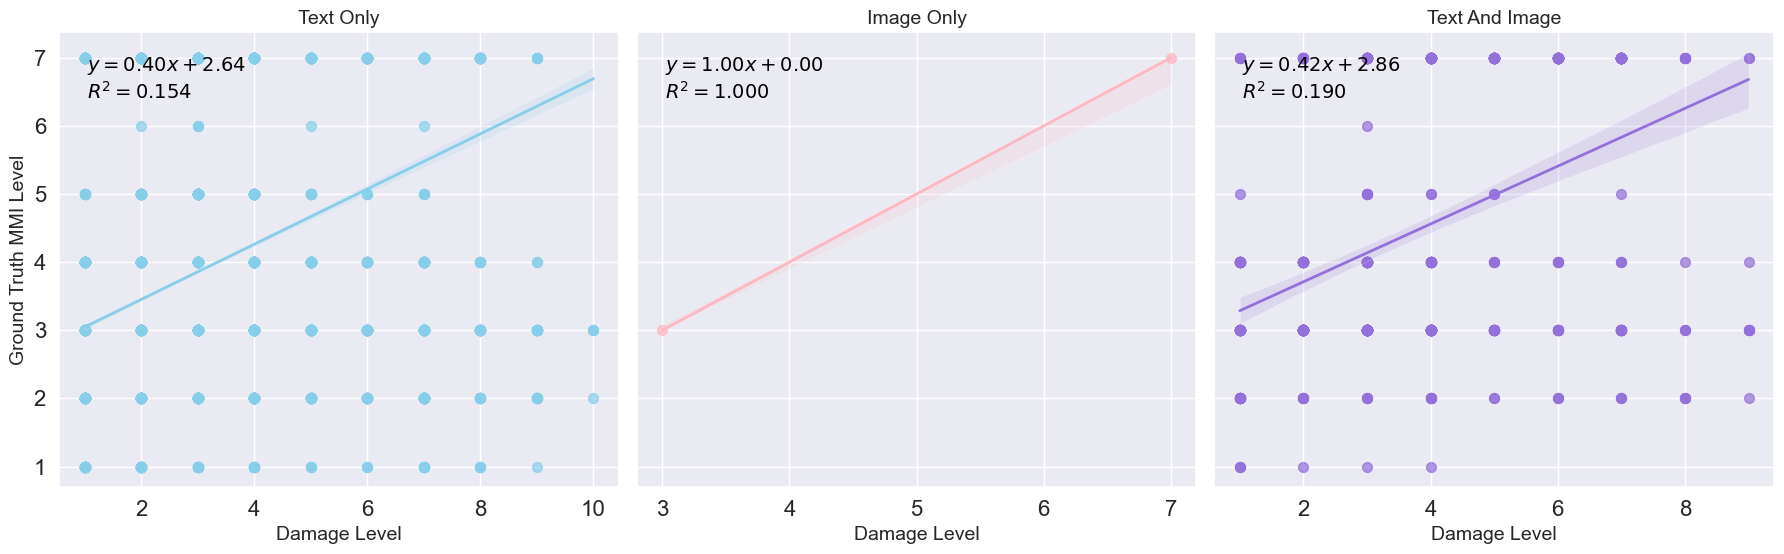

: 

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

# Set seaborn style
sns.set_theme(style="darkgrid")

# Load dataset
df = pd.read_csv("gemini_voted_model_merged.csv")  # Update path if needed

# Standardize 'voted' column
voted_mapping = {
    'text only': 'text only',
    'Text Only': 'text only',
    'Image Only': 'image only',
    'Text + Image': 'text and image'
}
df['voted'] = df['voted'].map(voted_mapping)

# Filter to valid categories
valid_votes = ['text only', 'image only', 'text and image']
df_all = df[df['voted'].isin(valid_votes)].dropna(subset=['damage_level', 'MMI_numeric'])

# Convert to numeric
df_all['damage_level'] = df_all['damage_level'].astype(float)
df_all['MMI_numeric'] = df_all['MMI_numeric'].astype(float)

# Define colors
category_colors = {
    'text only': '#87CEEB',     # sky blue
    'image only': '#FFB6C1',    # light pink
    'text and image': '#9370DB' # purple
}

# Create subplots for each group
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
groups = ['text only', 'image only', 'text and image']

for ax, group in zip(axes, groups):
    group_df = df_all[df_all['voted'] == group]

    if len(group_df) < 2:
        ax.set_title(f"{group}\n(No data)")
        continue

    # Regression plot with seaborn
    sns.regplot(
        data=group_df,
        x='damage_level',
        y='MMI_numeric',
        color=category_colors[group],
        ax=ax,
        scatter_kws={'s': 50, 'alpha': 0.7},
        line_kws={'linewidth': 2}
    )

    # Regression line calculation
    X = group_df['damage_level'].values.reshape(-1, 1)
    y = group_df['MMI_numeric'].values
    model = LinearRegression().fit(X, y)
    slope = model.coef_[0]
    intercept = model.intercept_
    r_squared = r2_score(y, model.predict(X))
    r, _ = pearsonr(group_df['damage_level'], group_df['MMI_numeric'])

    # Annotate regression equation and R²
    ax.text(
        0.05, 0.95,
        f"$y = {slope:.2f}x + {intercept:.2f}$\n$R^2 = {r_squared:.3f}$",
        transform=ax.transAxes,
        fontsize=14,
        color='black',
        verticalalignment='top'
    )

    ax.set_title(group.title(), fontsize=14)
    ax.set_xlabel("Damage Level",fontsize=14)
    ax.tick_params(axis='both', labelsize=16)
    if ax == axes[0]:
        ax.set_ylabel("Ground Truth MMI Level",fontsize=14)
    else:
        ax.set_ylabel("")

# Final layout
#plt.suptitle("Regression by Voted Category (Styled)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


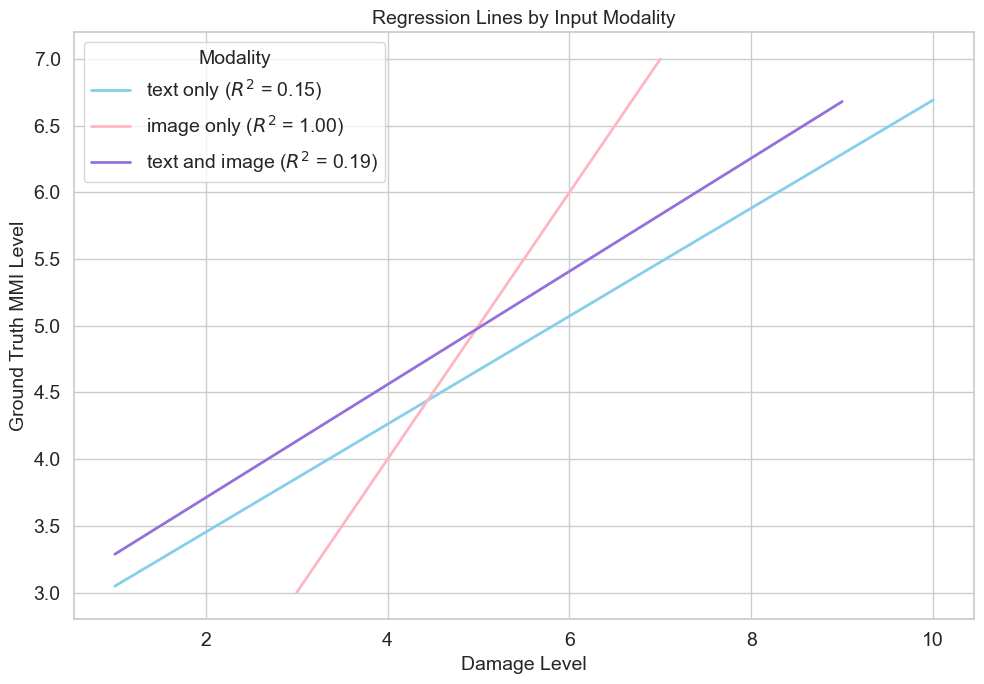

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import numpy as np

# Load data
df = pd.read_csv("gemini_voted_model_merged.csv")  # Update path if needed

# Standardize 'voted' column
voted_mapping = {
    'text only': 'text only',
    'Text Only': 'text only',
    'Image Only': 'image only',
    'Text + Image': 'text and image'
}
df['voted'] = df['voted'].map(voted_mapping)

# Filter and clean
valid_votes = ['text only', 'image only', 'text and image']
df_all = df[df['voted'].isin(valid_votes)].dropna(subset=['damage_level', 'MMI_numeric'])
df_all['damage_level'] = df_all['damage_level'].astype(float)
df_all['MMI_numeric'] = df_all['MMI_numeric'].astype(float)

# Set Seaborn theme and styling
sns.set_theme(style="whitegrid", rc={
    "font.family": "Arial",
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

# Color palette
category_colors = {
    'text only': '#87CEEB',
    'image only': '#FFB6C1',
    'text and image': '#9370DB'
}

# Plot setup
plt.figure(figsize=(10, 7))

# Draw regression lines only (no scatter), with R² in legend
for group in valid_votes:
    group_df = df_all[df_all['voted'] == group]
    if len(group_df) < 2:
        continue

    X = group_df['damage_level'].values.reshape(-1, 1)
    y = group_df['MMI_numeric'].values

    # Fit regression model
    model = LinearRegression().fit(X, y)
    r_squared = model.score(X, y)

    # Predict over range
    x_vals = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_vals = model.predict(x_vals)

    # Plot line
    plt.plot(x_vals, y_vals, label=f"{group} ($R^2$ = {r_squared:.2f})",
             color=category_colors[group], linewidth=2)

# Labels and layout
plt.xlabel("Damage Level", fontsize=14)
plt.ylabel("Ground Truth MMI Level", fontsize=14)
plt.title("Regression Lines by Input Modality", fontsize=14)
plt.legend(title="Modality", fontsize=14, title_fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()


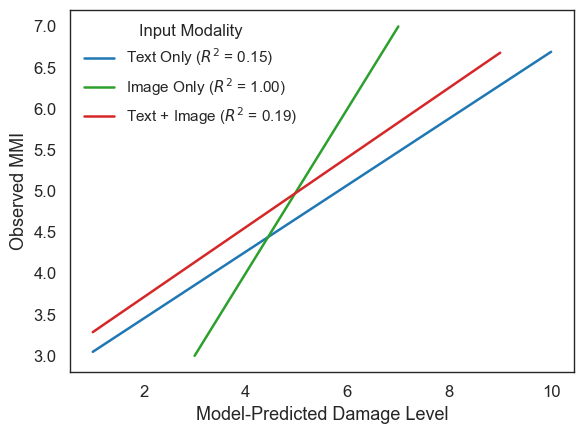

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# Load dataset
df = pd.read_csv("gemini_voted_model_merged.csv")

# Normalize the voting categories
df['voted'] = df['voted'].map({
    'text only': 'Text Only',
    'Text Only': 'Text Only',
    'Image Only': 'Image Only',
    'Text + Image': 'Text + Image'
})

# Filter dataset
valid_votes = ['Text Only', 'Image Only', 'Text + Image']
df_all = df[df['voted'].isin(valid_votes)].dropna(subset=['damage_level', 'MMI_numeric'])
df_all['damage_level'] = df_all['damage_level'].astype(float)
df_all['MMI_numeric'] = df_all['MMI_numeric'].astype(float)

# Academic-style Seaborn theme
sns.set_theme(style="white", rc={
    "font.family": "serif",
    "font.serif": ["Arial", "DejaVu Serif"],
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.linewidth": 1.0,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8
})

# Soft academic palette
palette = {
    'Text Only': '#1f77b4',
    'Image Only': '#2ca02c',
    'Text + Image': '#d62728'
}

# Create figure
plt.figure(figsize=(6, 4.5))

# Draw regression lines with R² values
for group in valid_votes:
    group_df = df_all[df_all['voted'] == group]
    if len(group_df) < 2:
        continue

    X = group_df['damage_level'].values.reshape(-1, 1)
    y = group_df['MMI_numeric'].values

    model = LinearRegression().fit(X, y)
    r_squared = model.score(X, y)

    x_vals = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_vals = model.predict(x_vals)

    plt.plot(x_vals, y_vals, label=f"{group} ($R^2$ = {r_squared:.2f})", color=palette[group], linewidth=1.8)

# Axis labels
plt.xlabel("Model-Predicted Damage Level", fontsize=13)
plt.ylabel("Observed MMI", fontsize=13)

# Legend & layout
plt.legend(title="Input Modality", title_fontsize=12, fontsize=11, frameon=False, loc='upper left')
plt.tight_layout()
plt.show()


Some testing

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score


# -------------------------
# Assume your dataset is loaded here
# -------------------------
df = pd.read_csv("city_count_remian_llava_mmi.csv")


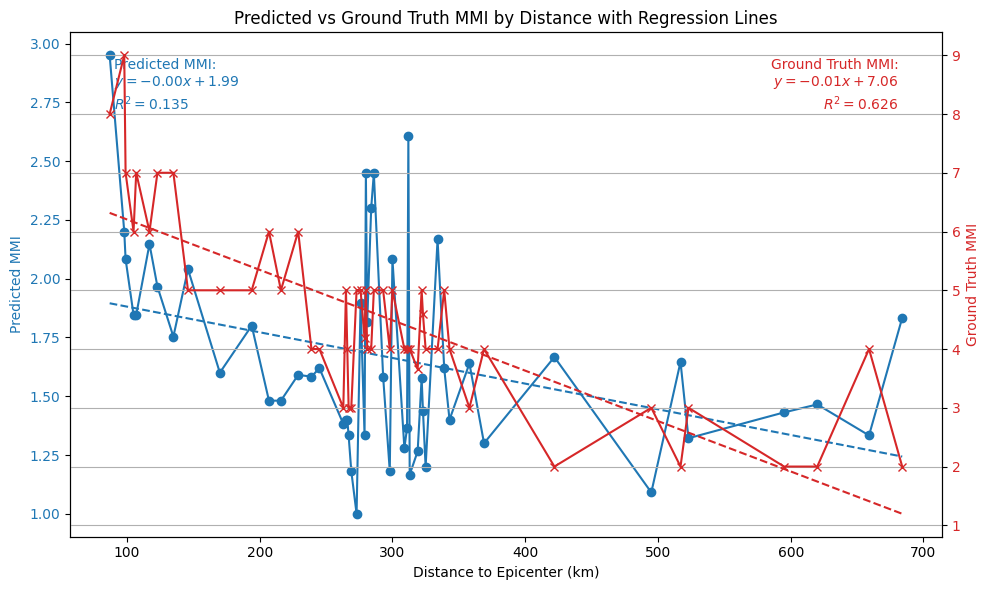

In [4]:
# --- Step 2: Clean columns ---
df = df[['City', 'damage_lev', 'MMI_numeric', 'Distance']].dropna()

# Clean distance (if in "500 km" format)
df['Distance'] = (
    df['Distance'].astype(str)
    .str.replace('km', '', case=False)
    .str.replace(',', '')
    .str.strip()
)
df['Distance'] = pd.to_numeric(df['Distance'], errors='coerce')

# --- Step 3: Filter valid cities (≥10 tweets) ---
city_counts = df['City'].value_counts()
valid_cities = city_counts[city_counts >= 10].index
df = df[df['City'].isin(valid_cities)]

# --- Step 4: Round distance for grouping ---
df['Distance_rounded'] = df['Distance'].round()

# --- Step 5: Aggregate by distance ---
avg_mmi_by_distance = (
    df.groupby('Distance_rounded')
    .agg(mean_predicted_mmi=('damage_lev', 'mean'),
         mean_ground_truth_mmi=('MMI_numeric', 'mean'),
         count=('damage_lev', 'count'))
    .reset_index()
)

# Keep only bins with enough data points
avg_mmi_by_distance = avg_mmi_by_distance[avg_mmi_by_distance['count'] >= 3]

# --- Step 6: Fit regression models ---
X = avg_mmi_by_distance['Distance_rounded'].values.reshape(-1, 1)

# Predicted MMI
y_pred = avg_mmi_by_distance['mean_predicted_mmi'].values
model_pred = LinearRegression().fit(X, y_pred)
line_pred = model_pred.predict(X)
r2_pred = r2_score(y_pred, line_pred)

# Ground Truth MMI
y_true = avg_mmi_by_distance['mean_ground_truth_mmi'].values
model_true = LinearRegression().fit(X, y_true)
line_true = model_true.predict(X)
r2_true = r2_score(y_true, line_true)

# --- Step 7: Plot ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# Predicted MMI plot
ax1.plot(avg_mmi_by_distance['Distance_rounded'], y_pred,
         color='tab:blue', marker='o', label='Predicted MMI')
ax1.plot(avg_mmi_by_distance['Distance_rounded'], line_pred,
         color='tab:blue', linestyle='--')
ax1.set_xlabel("Distance to Epicenter (km)")
ax1.set_ylabel("Predicted MMI", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Ground Truth MMI plot
ax2 = ax1.twinx()
ax2.plot(avg_mmi_by_distance['Distance_rounded'], y_true,
         color='tab:red', marker='x', label='Ground Truth MMI')
ax2.plot(avg_mmi_by_distance['Distance_rounded'], line_true,
         color='tab:red', linestyle='--')
ax2.set_ylabel("Ground Truth MMI", color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Annotate regression results
ax1.text(0.05, 0.95,
         f"Predicted MMI:\n$y = {model_pred.coef_[0]:.2f}x + {model_pred.intercept_:.2f}$\n$R^2 = {r2_pred:.3f}$",
         transform=ax1.transAxes, fontsize=10, color='tab:blue', verticalalignment='top')

ax2.text(0.95, 0.95,
         f"Ground Truth MMI:\n$y = {model_true.coef_[0]:.2f}x + {model_true.intercept_:.2f}$\n$R^2 = {r2_true:.3f}$",
         transform=ax2.transAxes, fontsize=10, color='tab:red', verticalalignment='top', horizontalalignment='right')

plt.title("Predicted vs Ground Truth MMI by Distance with Regression Lines")
plt.grid(True)
fig.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

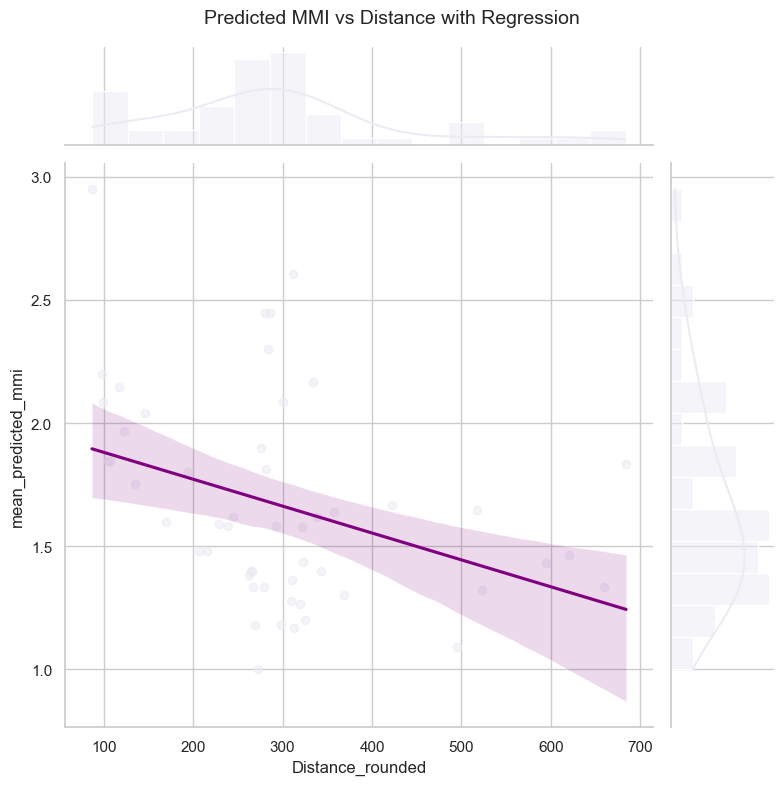

In [5]:
import seaborn as sns

# Apply a style similar to the reference (use 'whitegrid' and purple palette)
sns.set(style='whitegrid', context='notebook')
sns.set_palette("Purples")

# Create the plot: just Predicted MMI vs Distance (with histograms + regression)
plt.figure(figsize=(8, 6))
g = sns.jointplot(
    data=avg_mmi_by_distance,
    x='Distance_rounded',
    y='mean_predicted_mmi',
    kind='reg',
    height=8,
    scatter_kws=dict(alpha=0.6),
    line_kws=dict(color='purple'),
    marginal_kws=dict(bins=15, fill=True)
)

g.fig.suptitle("Predicted MMI vs Distance with Regression", fontsize=14)
plt.tight_layout()
plt.show()


C:\Users\missa\AppData\Local\Temp\ipykernel_32376\3632715849.py:79: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


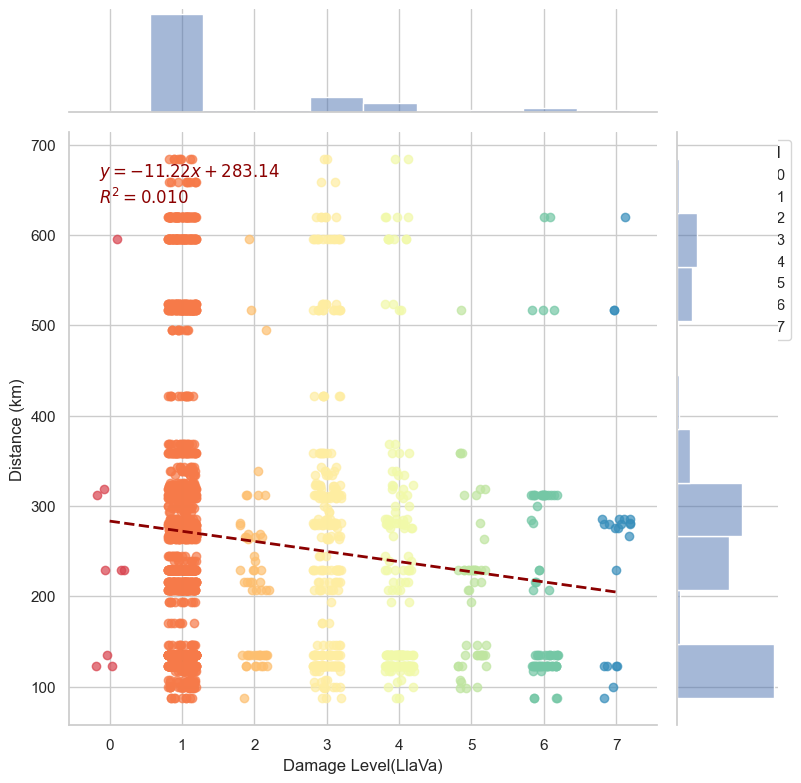

In [8]:
# -------------------------
# Step 2: Clean & Prepare Data
# -------------------------

# Keep only needed columns and drop NaNs
df_clean = df[['City', 'damage_lev', 'MMI_numeric', 'Distance']].dropna()

# Clean 'Distance' column (e.g., "295 km" -> 295)
df_clean['Distance'] = (
    df_clean['Distance']
    .astype(str)
    .str.replace('km', '', case=False)
    .str.replace(',', '')
    .str.strip()
)
df_clean['Distance'] = pd.to_numeric(df_clean['Distance'], errors='coerce')
df_clean = df_clean.dropna(subset=['Distance'])

# -------------------------
# Step 3: Filter Cities with ≥10 Tweets
# -------------------------
city_counts = df_clean['City'].value_counts()
valid_cities = city_counts[city_counts >= 10].index
df_clean = df_clean[df_clean['City'].isin(valid_cities)].copy()

# -------------------------
# Step 4: Prepare Predicted MMI and Jittered Axis
# -------------------------
df_clean['MMI_predicted_num'] = df_clean['damage_lev'].round().astype(int)

# Add jitter to predicted MMI
jitter_amount = 0.2
np.random.seed(42)
df_clean['x_jittered'] = df_clean['MMI_predicted_num'] + np.random.uniform(
    -jitter_amount, jitter_amount, size=len(df_clean)
)

# -------------------------
# Step 5: Linear Regression on Non-Jittered Values
# -------------------------
X_reg = df_clean['MMI_predicted_num'].values.reshape(-1, 1)
y_reg = df_clean['Distance'].values
model = LinearRegression().fit(X_reg, y_reg)
slope, intercept = model.coef_[0], model.intercept_
r_squared = r2_score(y_reg, model.predict(X_reg))

# -------------------------
# Step 6: Plot Using JointGrid
# -------------------------
sns.set(style='whitegrid', context='notebook')
g = sns.JointGrid(data=df_clean, x='x_jittered', y='Distance', height=8)

# Color-coded scatter plot by MMI level
palette = sns.color_palette("Spectral", n_colors=df_clean['MMI_predicted_num'].nunique())
for i, level in enumerate(sorted(df_clean['MMI_predicted_num'].unique())):
    subset = df_clean[df_clean['MMI_predicted_num'] == level]
    g.ax_joint.scatter(subset['x_jittered'], subset['Distance'],
                       label=f"MMI {level}", alpha=0.7, color=palette[i])

# Regression line (non-jittered MMI)
x_vals = np.linspace(df_clean['MMI_predicted_num'].min(), df_clean['MMI_predicted_num'].max(), 100)
y_vals = slope * x_vals + intercept
g.ax_joint.plot(x_vals, y_vals, linestyle='--', color='darkred', linewidth=2)

# Marginals
g.plot_marginals(sns.histplot, bins=10, fill=True, alpha=0.5)

# Annotate regression equation and R²
g.ax_joint.text(0.05, 0.95,
                f"$y = {slope:.2f}x + {intercept:.2f}$\n$R^2 = {r_squared:.3f}$",
                transform=g.ax_joint.transAxes,
                fontsize=12,
                color='darkred',
                verticalalignment='top')

g.set_axis_labels("Damage Level(LlaVa)", "Distance (km)")
g.ax_joint.legend(title="MMI Level", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

C:\Users\missa\AppData\Local\Temp\ipykernel_32376\2710013016.py:44: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


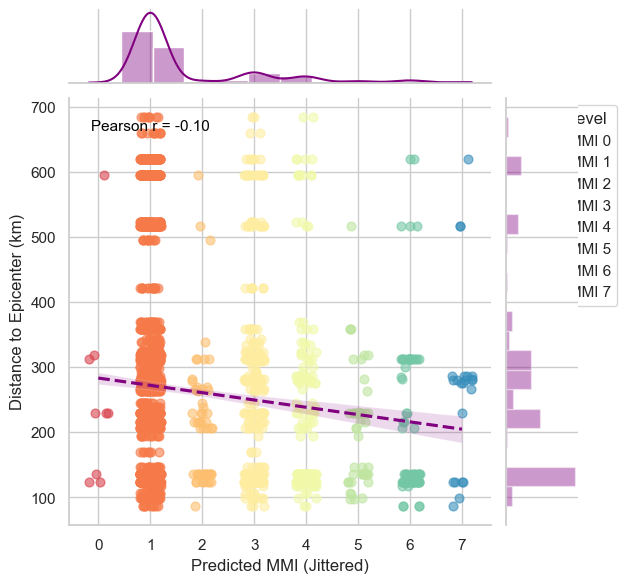

In [11]:
# Rebuild the JointGrid using corrected vertical marginal
sns.set(style='whitegrid', context='notebook')
g = sns.JointGrid(data=df_clean, x='x_jittered', y='Distance', height=6)

# Custom scatter by MMI level
palette = sns.color_palette("Spectral", n_colors=df_clean['MMI_predicted_num'].nunique())
for i, level in enumerate(sorted(df_clean['MMI_predicted_num'].unique())):
    subset = df_clean[df_clean['MMI_predicted_num'] == level]
    g.ax_joint.scatter(subset['x_jittered'], subset['Distance'],
                       label=f"MMI {level}", alpha=0.6, s=40, color=palette[i])

# Regression line using seaborn for prediction interval
sns.regplot(
    x='MMI_predicted_num', y='Distance', data=df_clean,
    scatter=False, ax=g.ax_joint, color='purple', line_kws={'linestyle': '--'}
)

# Top marginal histogram + KDE
sns.histplot(df_clean['x_jittered'], ax=g.ax_marg_x, bins=12, kde=True, color='purple', alpha=0.4)

# Right marginal vertical histogram using matplotlib
counts, bins = np.histogram(df_clean['Distance'], bins=20)
g.ax_marg_y.barh(
    (bins[:-1] + bins[1:]) / 2,  # bin centers
    counts,
    height=np.diff(bins),
    color='purple',
    alpha=0.4
)

# Pearson correlation annotation
r_val, _ = pearsonr(df_clean['MMI_predicted_num'], df_clean['Distance'])
g.ax_joint.text(0.05, 0.95,
                f"Pearson r = {r_val:.2f}",
                transform=g.ax_joint.transAxes,
                fontsize=11,
                color='black',
                verticalalignment='top')

# Labels and legend
g.set_axis_labels("Predicted MMI (Jittered)", "Distance to Epicenter (km)")
g.ax_joint.legend(title="MMI Level", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()
